# Machine Learning으로 찾아보는 유저들의 사용패턴

KMeans 클러스터링으로 알람 앱 유저의 **사용 패턴(페르소나)** 을 비지도로 나눠 봅니다.
정답 라벨에 기대지 않고, 여러 피처의 조합으로 "유저들이 *어떻게* 서비스를 쓰는지"를
정형화하고, 중심점으로 해석·네이밍한 뒤 핵심 지표(리텐션)와 연결해 액션까지 이어 봅니다.

실습 흐름:
- **8.5.2.** 유저 피처 만들기 — 8.5.2.1 유저 피처 추출 (도메인 특성을 담은 피처 엔지니어링 SQL) · 8.5.2.2 피처 분포 확인 (유저 간 변별력이 있는가)
- **8.5.3.** 피처 스케일링 + 클러스터 개수 정하기 (Elbow · Silhouette)
- **8.5.4.** 클러스터링 — 8.5.4.1 중심점으로 특성 읽기 → 페르소나 네이밍 · 8.5.4.2 PCA로 클러스터 시각화
- **8.5.5.** 코호트와 지표를 추가하여 클러스터링 활용 — 8.5.5.1 신규/기존 유저로 나눠 클러스터링 · 8.5.5.2 클러스터별 리텐션 KPI → 액션 연결 · 8.5.5.3 라벨 적재 & 모델 저장/로드

> 예시 데이터는 4개 페르소나를 '심어' 만든 합성 데이터입니다. KMeans 가 그 페르소나를
> 거의 그대로 복원하는지 확인하며 따라가면 됩니다.

## 8.5.1. 실습용 데이터 준비

데이터가 없다면 먼저 `python generate_data.py` 로 예시 데이터를 생성하세요
(`data/alarm_daily.csv`, `data/user_master.csv`). 아래 첫 셀이 의존성을 설치합니다.
노트북을 끝까지 실행하면 유저별 클러스터 라벨(`output/`)과 KMeans 모델 파일(`models/`)이 함께 생성됩니다.

실습에 쓰는 두 테이블은 다음과 같습니다.

- `alarm_daily.csv` — 유저-일자별 알람 사용 로그. `local_date`(사용 일자), `user_id`, `scheduled_cnt`(그날 맞춰 둔 알람 개수),
  `first_scheduled_min`·`last_scheduled_min`(첫/마지막 알람 시각, 자정 기준 분 — 예: 382 = 06:22), `snooze_alarm_cnt`(스누즈된 알람 수),
  `mission_used_cnt`(미션을 사용한 알람 수), `mission_attempt_cnt`(미션 시도 횟수), `total_time_to_dismiss`(알람 해제까지 걸린 총 시간, 분),
  `first_ring_to_last_dismiss`(첫 알람이 울린 뒤 마지막 해제까지의 시간 = 기상에 걸린 시간, 분)
- `user_master.csv` — 유저당 한 행짜리 마스터. `user_id`, `new_flag`(신규 유저 여부), `retained_d7`(7일 차 잔존 여부).
  8.5.5.1의 코호트 구분과 8.5.5.2의 리텐션 KPI 연결에 사용합니다.

In [ ]:
# 의존성 설치 (이미 설치돼 있으면 빠르게 넘어갑니다)
# %pip 매직은 현재 커널 환경에 설치하므로 PATH 문제 없이 동작합니다.
%pip install -q -r requirements.txt

In [2]:
import pickle, os
import numpy as np
import pandas as pd
import duckdb
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

con = duckdb.connect()

# --- 책 공통 차트 스타일 (팔레트·그리드·spine 통일) ---
PALETTE = ["#1f9d78", "#3b4556", "#d97706", "#6b7380"]  # green, slate, amber, muted
plt.rcParams.update({
    "axes.prop_cycle": plt.cycler(color=PALETTE),
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.grid.axis": "y", "grid.alpha": 0.3,
    "figure.dpi": 150, "legend.frameon": False,
})

## 8.5.2. 유저 피처 만들기

### 8.5.2.1. 유저 피처 추출

기본이라고 생각되는 유저별 알람 개수와 함께 전체 기상 시간, 스누즈 비율, 미션 비율 등의 피처를 추출하고,
이상치 제거를 위해 간단한 클리핑 로직을 적용합니다. 이론에서 강조한 도메인 특성이 이 SQL에 그대로 녹아 있습니다. 주중(월~금)만 필터링하고,
기간 평균으로 하루치 노이즈를 누르며, 알람 개수·인터벌·기상 시간·미션 등 한 단계 더
내려간 피처를 만듭니다. 클러스터 입력용으로는 극단값을 클리핑한 `_cluster` 버전을 따로 둡니다.
(`sql/extract_features.sql` 와 동일한 쿼리)

코드는 DuckDB로 CSV 파일을 바로 SQL로 다룰 수 있게 시작합니다. 먼저 일별 로그를 하루 단위 파생 지표로 바꾼 뷰와, 극단값을 자르는 clip 매크로를 등록해 둡니다.

In [3]:
con.execute("""
CREATE OR REPLACE MACRO clip(x, lim, cap) AS CASE WHEN x > lim THEN cap ELSE x END;  -- 극단값 클리핑

-- 일별 알람 로그 → 하루 단위 파생 지표. 주중(월~금)만 쓴다 (주중/주말 패턴이 극명히 다르므로)
CREATE OR REPLACE VIEW daily_stat AS
  SELECT local_date, user_id, scheduled_cnt,
         (last_scheduled_min - first_scheduled_min) / NULLIF(scheduled_cnt - 1, 0) AS avg_interval,
         snooze_alarm_cnt      / scheduled_cnt AS avg_snooze,
         mission_used_cnt      / scheduled_cnt AS used_mission_per_alarm,
         mission_attempt_cnt   / scheduled_cnt AS mission_attempt_per_alarm,
         total_time_to_dismiss / scheduled_cnt AS avg_time_to_dismiss,
         first_ring_to_last_dismiss
  FROM read_csv_auto('data/alarm_daily.csv')
  WHERE isodow(CAST(local_date AS DATE)) BETWEEN 1 AND 5   -- DuckDB isodow: Mon=1
    AND scheduled_cnt > 0
    AND first_ring_to_last_dismiss > 0
""")

유저 단위로 기간 평균을 내고, 클러스터 입력용 클리핑 버전(_cluster)을 함께 만듭니다.

In [4]:
query = """
WITH user_features AS (   -- 기간 평균으로 하루치 노이즈를 누른다
  SELECT user_id,
         AVG(scheduled_cnt)                AS scheduled_cnt,
         AVG(COALESCE(avg_interval, 0))    AS avg_interval,
         AVG(avg_snooze)                   AS avg_snooze,
         AVG(used_mission_per_alarm)       AS used_mission_per_alarm,
         AVG(mission_attempt_per_alarm)    AS mission_attempt_per_alarm,
         AVG(avg_time_to_dismiss)          AS avg_time_to_dismiss,
         AVG(first_ring_to_last_dismiss)   AS first_ring_to_last_dismiss
  FROM daily_stat
  GROUP BY user_id
)
SELECT m.new_flag, m.retained_d7, u.*,
       -- 클러스터 입력용: 극단값 클리핑 버전 — clip(값, 상한, 대체값)
       clip(scheduled_cnt, 10, 11)                AS scheduled_cnt_cluster,
       clip(avg_interval, 60, 65)                 AS avg_interval_cluster,
       clip(avg_snooze, 10, 11)                   AS avg_snooze_cluster,
       clip(used_mission_per_alarm, 10, 11)       AS used_mission_cluster,
       clip(mission_attempt_per_alarm, 10, 11)    AS mission_attempt_cluster,
       clip(avg_time_to_dismiss, 120, 125)        AS avg_time_to_dismiss_cluster,
       clip(first_ring_to_last_dismiss, 120, 125) AS first_ring_to_last_dismiss_cluster
FROM user_features AS u
LEFT JOIN read_csv_auto('data/user_master.csv') AS m USING (user_id)
ORDER BY user_id
"""
df = con.execute(query).df()
print("users:", len(df))
df.head()

users: 2400


,new_flag,retained_d7,user_id,scheduled_cnt,avg_interval,avg_snooze,used_mission_per_alarm,mission_attempt_per_alarm,avg_time_to_dismiss,first_ring_to_last_dismiss,scheduled_cnt_cluster,avg_interval_cluster,avg_snooze_cluster,used_mission_cluster,mission_attempt_cluster,avg_time_to_dismiss_cluster,first_ring_to_last_dismiss_cluster
0,False,False,u00001,1.6,15.00,1.000000,1.000000,1.400000,68.940000,74.77,1.6,15.00,1.000000,1.000000,1.400000,68.940000,74.77
1,False,False,u00002,1.4,7.45,0.750000,0.916667,1.450000,67.641667,75.49,1.4,7.45,0.750000,0.916667,1.450000,67.641667,75.49
2,False,False,u00003,1.4,6.75,0.966667,1.000000,1.283333,67.498333,74.51,1.4,6.75,0.966667,1.000000,1.283333,67.498333,74.51
3,False,False,u00004,1.9,15.55,1.000000,0.950000,1.300000,67.601667,76.41,1.9,15.55,1.000000,0.950000,1.300000,67.601667,76.41
4,False,False,u00005,1.2,4.70,1.000000,0.900000,1.150000,68.475000,75.49,1.2,4.70,1.000000,0.900000,1.150000,68.475000,75.49


### 8.5.2.2. 피처 분포 확인하기

"유저 간 차이가 드러나는 피처인가"를 분포로 점검합니다. 모든 유저가 비슷한 값을 갖는
피처는 변별력이 없으므로, 클러스터링에 넣기 전에 히스토그램으로 한 번 훑어봅니다.

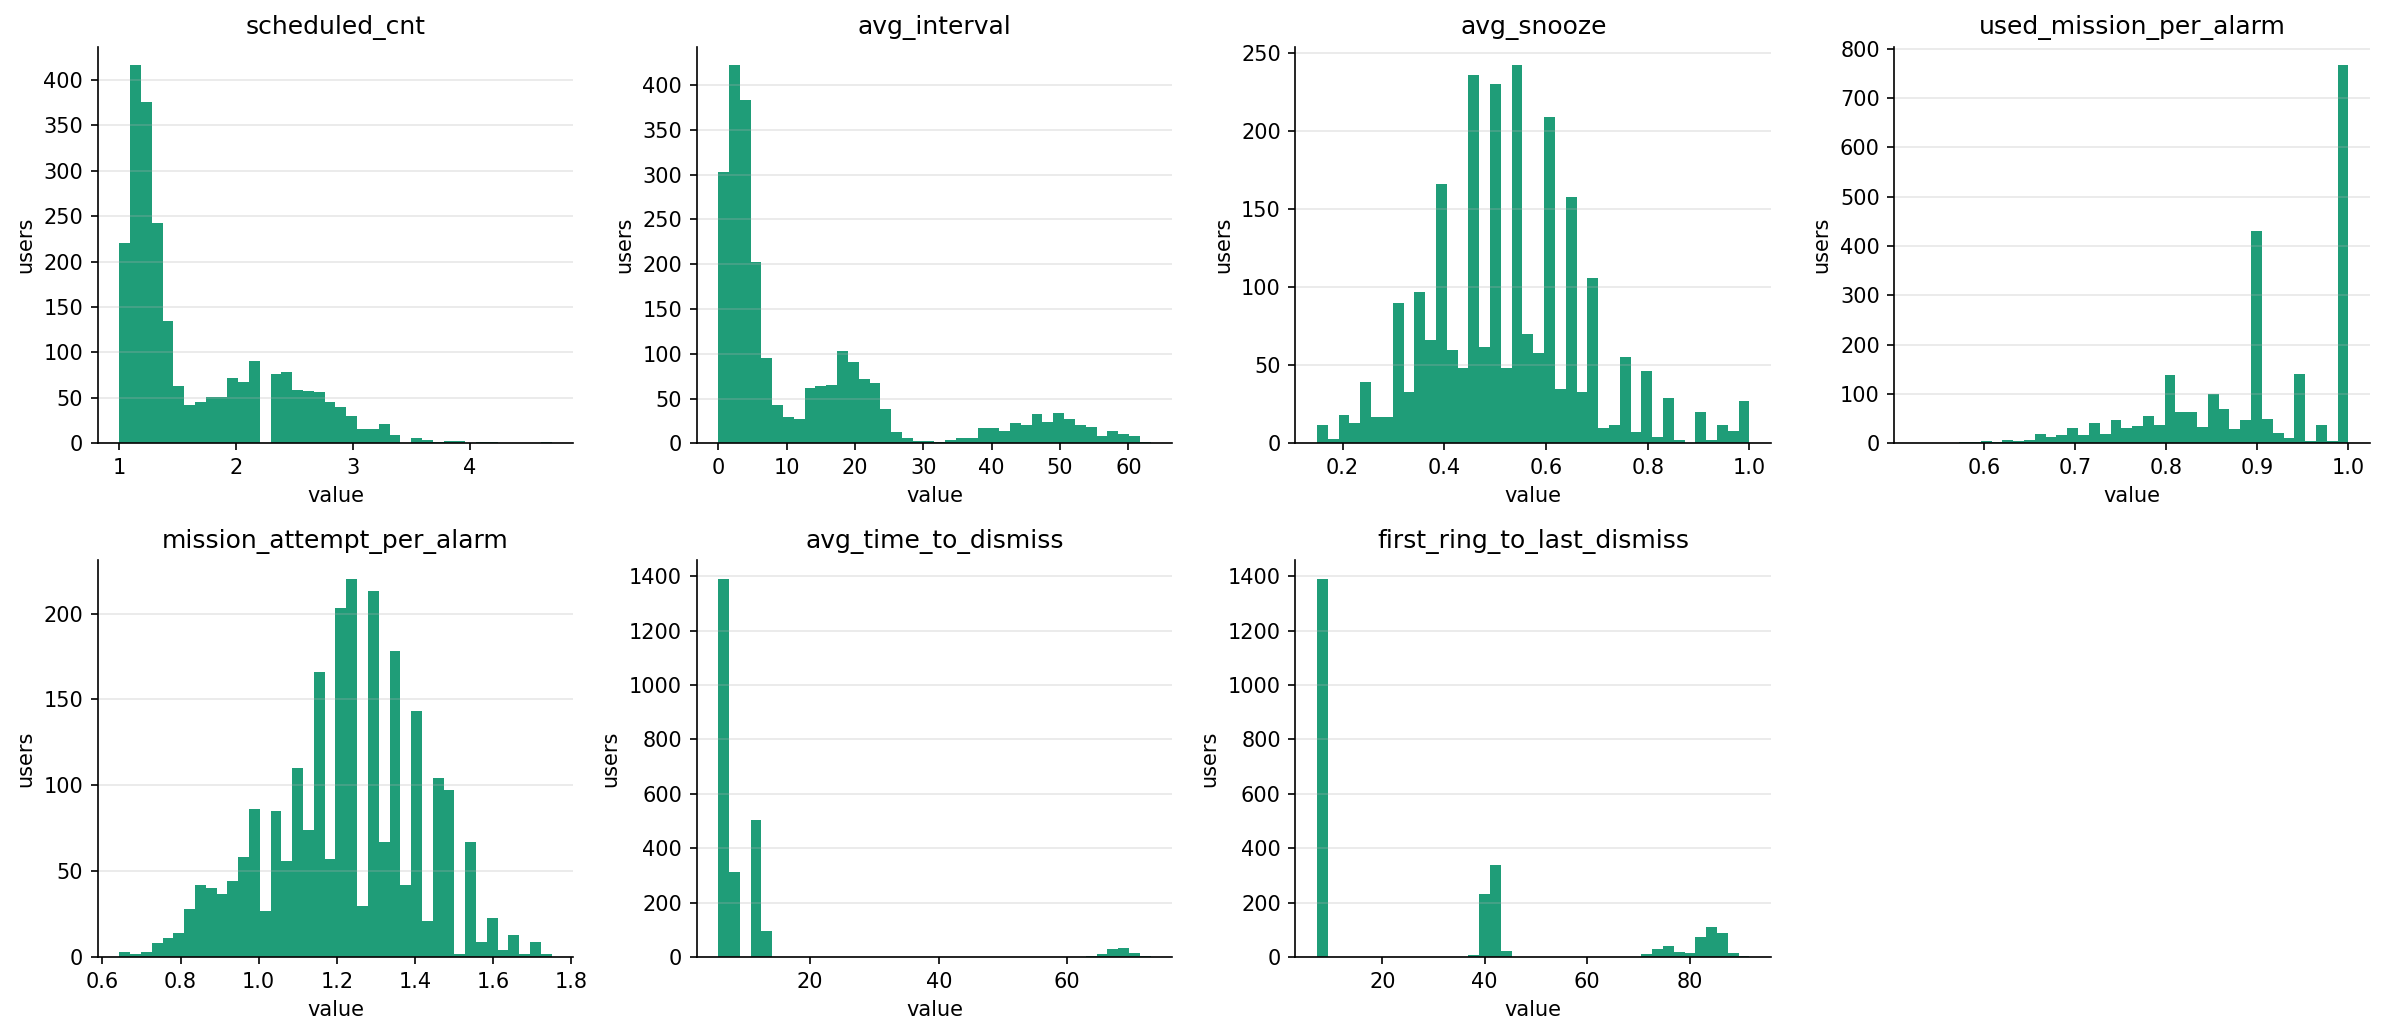

In [5]:
# 피처별 분포로 유저 간 변별력 확인 (모두 비슷한 값이면 군집 분리에 쓸모가 없다)
feat_cols = ['scheduled_cnt', 'avg_interval', 'avg_snooze',
             'used_mission_per_alarm', 'mission_attempt_per_alarm',
             'avg_time_to_dismiss', 'first_ring_to_last_dismiss']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.ravel(), feat_cols):
    ax.hist(df[col].dropna(), bins=40, color='#1f9d78')
    ax.set_title(col); ax.set_xlabel('value'); ax.set_ylabel('users')
axes.ravel()[-1].set_visible(False)   # 7개 피처 → 빈 칸 숨김
plt.tight_layout(); plt.show()

## 8.5.3. 피처 스케일링 + 클러스터 개수 정하기

**왜 스케일링이 필요할까요?** KMeans 는 점 사이의 유클리드 거리로 군집을 나눕니다.
그런데 `first_ring_to_last_dismiss`(기상 시간, 0~120분)와 `avg_snooze`(알람별 스누즈, 0~1대)는
스케일이 수십~100배 차이가 납니다. 그대로 넣으면 거리 계산을 큰 범위의 피처가 독식해
사실상 한 피처로만 군집화되는 셈이죠. `StandardScaler` 로 각 피처를 평균 0·표준편차 1로
표준화해 모든 피처가 공평하게 기여하도록 만듭니다.

In [6]:
# 클러스터 입력: 극단값을 클리핑해 둔 _cluster 피처만 사용
cluster_cols = [c for c in df.columns if c.endswith('_cluster')]
X = df[cluster_cols].dropna()

# 표준화(평균 0·표준편차 1): 거리 기반인 KMeans에서 스케일 큰 피처가 거리 계산을 독식하지 않도록
scaler = StandardScaler().fit(X)
X_scaled = scaler.transform(X)

print('clustering features:', [c.replace('_cluster', '') for c in cluster_cols])
print('X shape:', X_scaled.shape)

clustering features: ['scheduled_cnt', 'avg_interval', 'avg_snooze', 'used_mission', 'mission_attempt', 'avg_time_to_dismiss', 'first_ring_to_last_dismiss']
X shape: (2400, 7)


이제 Elbow Method(inertia)와 Silhouette score를 함께 그려 클러스터 개수 `k` 를 정합니다.
Elbow 는 inertia의 기울기가 꺾이는 지점, Silhouette 는 군집 분리가 가장 또렷한 지점을 봅니다.
다만 "팀이 이해하고 관리할 수 있는 개수"라는 현실적 기준도 함께 고려합니다.

표준화한 행렬로 k를 1~10까지 바꿔 가며 Elbow(inertia)와 Silhouette 점수를 함께 그립니다.

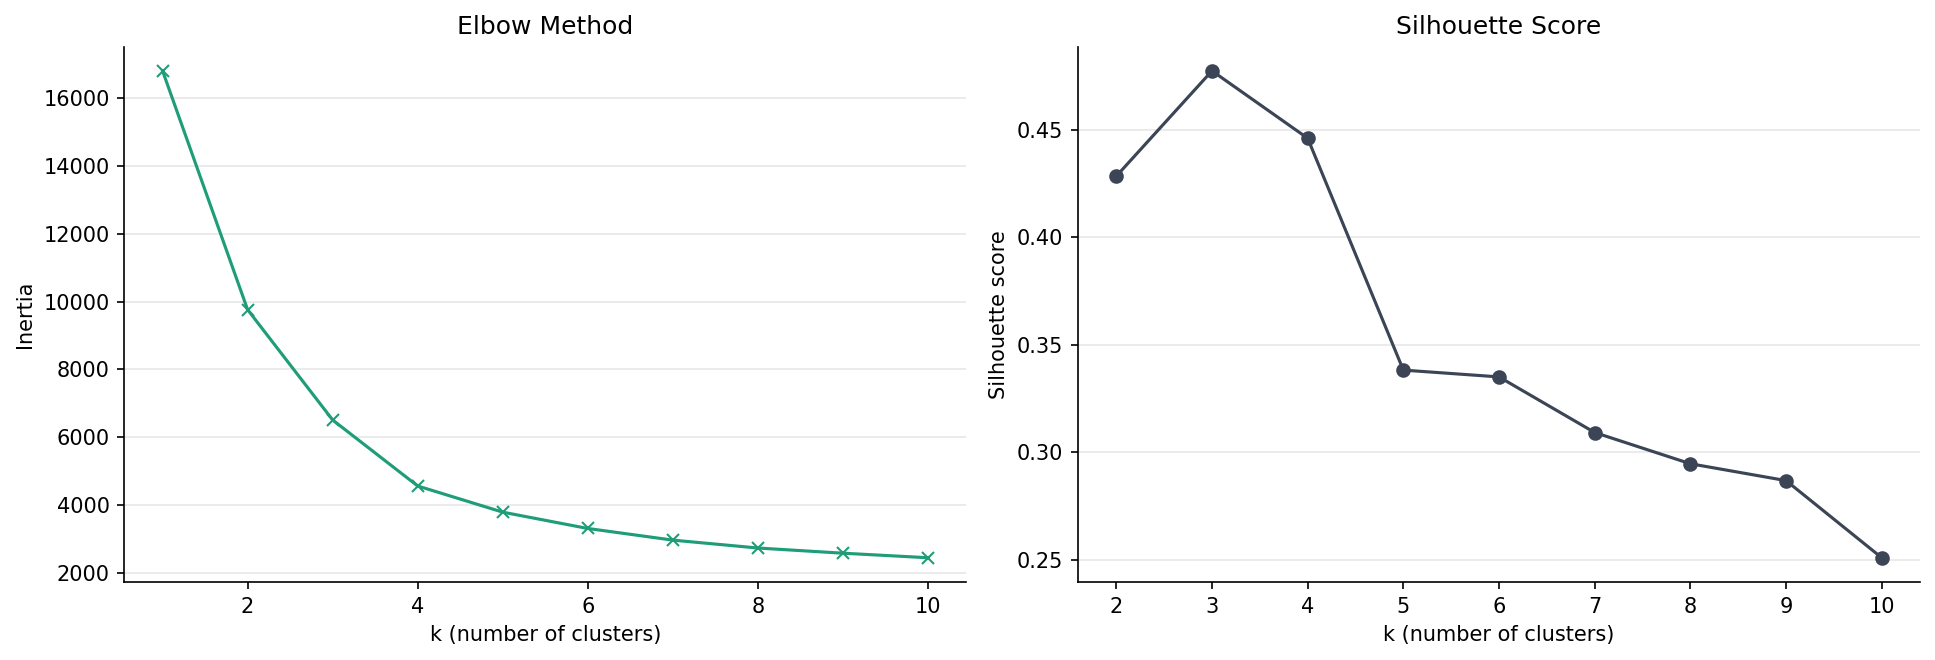

In [7]:
# k를 1~10으로 바꿔가며 inertia(군집 내 거리 제곱합) 측정 → 기울기가 꺾이는 지점이 Elbow
k_values = range(1, 11)
inertias = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled).inertia_
            for k in k_values]

# silhouette: 군집이 얼마나 잘 분리됐는지 (-1~1, 클수록 좋음)
sil_values = range(2, 11)
silhouettes = [silhouette_score(X_scaled, KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled).labels_)
               for k in sil_values]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
ax1.plot(list(k_values), inertias, 'x-', color='#1f9d78')
ax1.set_xlabel('k (number of clusters)'); ax1.set_ylabel('Inertia'); ax1.set_title('Elbow Method')
ax2.plot(list(sil_values), silhouettes, 'o-', color='#3b4556')
ax2.set_xlabel('k (number of clusters)'); ax2.set_ylabel('Silhouette score'); ax2.set_title('Silhouette Score')
plt.tight_layout(); plt.show()

## 8.5.4. 클러스터링

### 8.5.4.1. 중심점으로 특성 읽기

이번 예시에서는 본문에서 봤던 클러스터(표 8.1·표 8.2)가 그대로 잘 복원되는지 확인해 봅니다.
위에서 정한 `k` 로 KMeans를 적합하고, 각 클러스터를 대변하는 중심점을 한 표로 모아 특성을 읽은 뒤, 8.5.4.2의 시각화로 한 번 더 검증합니다.
중심점은 표준화된 공간에 있으므로, `scaler.inverse_transform` 으로 **원래 단위(분·개수)** 로
되돌려 해석의 해상도를 높입니다. KMeans는 중심점 기반 알고리즘이라, 중심점이 곧 그 클러스터의 대표 패턴입니다.

In [8]:
def fit_kmeans(frame, k=4):
    # 스케일링 → KMeans → 중심점을 원단위로 복원. 8.5.5.1(신규/기존 비교)에서도 그대로 재사용한다
    # 새 데이터를 같은 기준으로 변환할 수 있도록 학습에 쓴 scaler 도 함께 반환한다
    cols = [c for c in frame.columns if c.endswith('_cluster')]
    X = frame[cols].dropna()
    scaler = StandardScaler().fit(X)
    model = KMeans(n_clusters=k, random_state=42, n_init=10).fit(scaler.transform(X))
    centers = pd.DataFrame(scaler.inverse_transform(model.cluster_centers_),
                           columns=[c.replace('_cluster', '') for c in cols])
    return model, scaler, X, model.labels_, centers

k = 4
kmeans, scaler, X, raw_labels, centers = fit_kmeans(df, k)

# 중심값을 읽어 페르소나 이름 부여 (알람 수 = 미니멀/맥시멀, 기상 시간 = 의지박약 여부)
PERSONA_ORDER = ['의지박약 미니멀리스트', '미니멀리스트', '의지박약 맥시멀리스트', '노력형 맥시멀리스트']
def name_persona(r):
    if r['scheduled_cnt'] < 2:                                  # 알람 ~1개 = 미니멀리스트
        return '의지박약 미니멀리스트' if r['first_ring_to_last_dismiss'] > 40 else '미니멀리스트'
    return '의지박약 맥시멀리스트' if r['first_ring_to_last_dismiss'] > 60 else '노력형 맥시멀리스트'
centers['persona'] = centers.apply(name_persona, axis=1)

KMeans 라벨 번호는 실행마다 임의로 붙기 때문에, 페르소나 순서대로 0~3으로 재매핑한 뒤 한국어 헤더와 비중을 붙여 요약표를 만듭니다.

In [9]:
# KMeans 라벨 번호는 임의이므로, 페르소나 순서(PERSONA_ORDER)대로 0~3으로 재매핑
centers['cluster'] = centers['persona'].map({n: i for i, n in enumerate(PERSONA_ORDER)})
labels = pd.Series(raw_labels).map(dict(zip(centers.index, centers['cluster']))).to_numpy()

# 이후 단계(PCA·리텐션)에서 쓰도록 라벨을 df에 부착
df_labeled = df.loc[X.index].copy()
df_labeled['cluster'] = labels

# 한국어 헤더 + 비중으로 요약표 정리
KOR = {'scheduled_cnt': '알람 개수', 'avg_interval': '알람 사이 인터벌(분)',
       'avg_snooze': '알람별 스누즈 횟수', 'used_mission': '알람별 사용 미션수',
       'mission_attempt': '알람별 미션 시도 수', 'avg_time_to_dismiss': '알람 해제까지 시간(분)',
       'first_ring_to_last_dismiss': '첫 알람부터 해제까지 시간(분)'}
summary = centers.set_index('cluster').sort_index().rename(columns=KOR)
summary.insert(0, '페르소나', summary.pop('persona'))
summary['Count'] = pd.Series(labels).value_counts()
summary['비중'] = (summary['Count'] / summary['Count'].sum() * 100).map('{:.2f}%'.format)
summary[list(KOR.values())] = summary[list(KOR.values())].round(2)
summary

,페르소나,알람 개수,알람 사이 인터벌(분),알람별 스누즈 횟수,알람별 사용 미션수,알람별 미션 시도 수,알람 해제까지 시간(분),첫 알람부터 해제까지 시간(분),Count,비중
cluster,,,,,,,,,,
0,의지박약 미니멀리스트,1.40,8.58,0.91,0.91,1.28,68.09,75.15,99,4.12%
1,미니멀리스트,1.19,3.14,0.52,0.95,1.31,6.21,8.41,1390,57.92%
2,의지박약 맥시멀리스트,2.80,47.88,0.39,0.78,0.91,8.35,84.48,312,13.00%
3,노력형 맥시멀리스트,2.17,18.42,0.55,0.82,1.16,11.93,40.41,599,24.96%


중심점 표를 읽으면 정규화된 유저 패턴이 보입니다. 알람 수(미니멀/맥시멀)와 기상 시간(의지박약 여부)을
기준으로 네 페르소나에 이름을 붙였습니다 (본문 표 8.1·표 8.2에 맞춰 클러스터 번호를 0~3으로 정렬했습니다):

- **0. 의지박약 미니멀리스트** — 알람 ~1개, 인터벌 ~9분인데 스누즈가 잦고, 미션 항상, 해제까지 ~68분·일어나는 데 ~75분. 비중이 가장 작습니다(4.12%).
- **1. 미니멀리스트** — 알람 ~1개, 인터벌 ~3분, 스누즈 절반, 미션 항상, 금방 일어남(~8분). 비중이 가장 큰 군집(57.92%).
- **2. 의지박약 맥시멀리스트** — 알람 ~3개에 매우 긴 인터벌(~48분), 스누즈는 잘 안 하고 미션도 적게 쓰며, 해제는 ~8분이지만 일어나는 데 ~84분.
- **3. 노력형 맥시멀리스트** — 알람 ~2개, 인터벌 ~18분, 스누즈 절반, 미션 항상, 해제 ~12분·기상 ~40분.

분석가에게는 이 정도 요약만으로도 액션 아이템을 떠올리기에 충분합니다 — 해제까지 오래 걸리는 클러스터 0에게는 더 많은 알람 설정을
유도하고, 알람을 많이 맞춰두고도 못 일어나는 클러스터 2에게는 더 강력한 기상 미션이나 유료 기능을 넛지해 보는 식이죠.
하지만 숫자를 나열하는 것보다 "이 군집은 *의지박약 미니멀리스트* 다"라고 페르소나 이름을 붙이면,
PM·디자이너 등 다른 이해관계자와 훨씬 쉽게 소통할 수 있습니다. 작명이 어렵다면 함께 일하는
팀원과 같이 붙여 보는 것도 좋은 방법입니다.

### 8.5.4.2. PCA로 클러스터 시각화하기

7개 피처를 2차원으로 줄여(PCA) 클러스터의 크기와 경계를 눈으로 확인합니다.

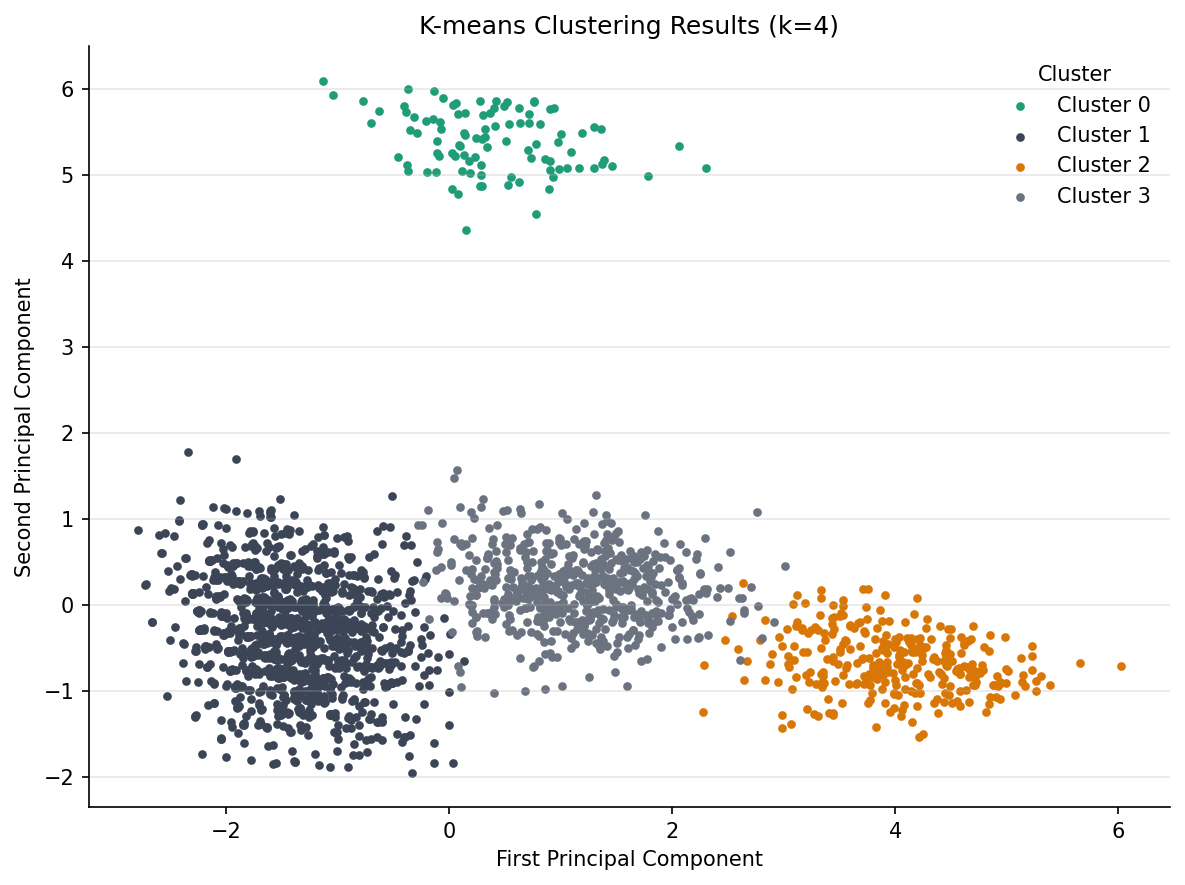

In [10]:
# 7개 피처를 2차원으로 투영(PCA)해 클러스터 크기·경계를 눈으로 확인
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(8, 6))
for c in sorted(set(labels)):
    mask = labels == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], s=10, label=f'Cluster {c}')
ax.set_xlabel('First Principal Component'); ax.set_ylabel('Second Principal Component')
ax.set_title(f'K-means Clustering Results (k={k})'); ax.legend(title='Cluster')
plt.tight_layout(); plt.show()

## 8.5.5. 코호트와 지표를 추가하여 클러스터링 활용

### 8.5.5.1. 신규/기존 유저로 나눠 클러스터링하기

이미 서비스 내에 유저를 구분하는 기준(여기서는 `new_flag`)이 있다면, 그룹을 나눠 각각
클러스터링해 사용 패턴 차이를 비교할 수 있습니다. 나아가 시간이 지나며 신규 유저가 어떤
기존 유저 클러스터로 이동하는지까지 추적해 행동 변화를 볼 수도 있습니다.
반복되는 적합·요약 과정을 함수로 묶었습니다 (스케일링도 내부에서 처리).

예시 데이터이긴 하지만, 신규와 기존 유저의 패턴은 비슷하나 그룹 간의 비율이 달라지는 것을 볼 수 있습니다.
다만 KMeans 라벨 번호는 모델마다 임의로 붙기 때문에, 신규/기존 출력을 비교할 때는 번호가 아니라 **중심점 값으로 같은 패턴끼리**
맞춰 보아야 합니다 — 아래 출력에서도 신규 유저의 0번과 기존 유저의 1번이 같은 미니멀리스트 패턴입니다.

In [11]:
def summarize(centers, labels):   # 중심점 표 + 유저 수
    out = centers.round(2); out.index.name = 'Cluster'
    out['count'] = pd.Series(labels).value_counts().sort_index()
    return out

# 신규/기존 유저에 같은 절차(fit_kmeans)를 따로 적용해 패턴 구성을 비교한다
df_new = df[df.new_flag == True]
model_new, scaler_new, X_new, labels_new, centers_new = fit_kmeans(df_new)
df_new = df_new.loc[X_new.index].copy(); df_new['label'] = labels_new

df_old = df[df.new_flag == False]
model_old, scaler_old, X_old, labels_old, centers_old = fit_kmeans(df_old)
df_old = df_old.loc[X_old.index].copy(); df_old['label'] = labels_old

print('신규 유저 클러스터 중심점'); display(summarize(centers_new, labels_new))
print('기존 유저 클러스터 중심점'); summarize(centers_old, labels_old)

신규 유저 클러스터 중심점


,scheduled_cnt,avg_interval,avg_snooze,used_mission,mission_attempt,avg_time_to_dismiss,first_ring_to_last_dismiss,count
Cluster,,,,,,,,
0,1.19,3.15,0.52,0.95,1.30,6.28,8.81,335
1,2.78,47.49,0.39,0.78,0.91,8.35,84.31,184
2,1.50,10.33,0.90,0.88,1.28,68.26,75.62,18
3,2.18,18.59,0.55,0.82,1.15,12.03,41.09,301


기존 유저 클러스터 중심점


,scheduled_cnt,avg_interval,avg_snooze,used_mission,mission_attempt,avg_time_to_dismiss,first_ring_to_last_dismiss,count
Cluster,,,,,,,,
0,1.38,8.19,0.91,0.92,1.28,68.05,75.05,81
1,1.19,3.13,0.52,0.95,1.32,6.18,8.25,1055
2,2.83,48.44,0.38,0.78,0.92,8.36,84.72,128
3,2.18,18.28,0.56,0.82,1.17,11.85,39.82,298


### 8.5.5.2. 클러스터별 리텐션 KPI → 액션 연결

클러스터를 나누는 것에서 멈추지 않고, 각 클러스터의 **핵심 지표**를 프로파일링해
"우리 서비스에 더 도움이 되는 사용 패턴"을 정의해 봅니다. 알람 앱에서 리텐션은 DAU와
직결되는 지표죠. 여기서는 D7 잔존율을 클러스터별로 봅니다.

> 주의: 리텐션은 **클러스터링 입력이 아닙니다**. 비지도로 나눈 군집을 *사후에* 평가하는
> 지표로만 씁니다 (라벨 bias 없이 패턴을 먼저 나눈 뒤 해석).

리텐션이 가장 높은 클러스터와 가장 낮은 클러스터를 비교해 보고, 성과가 높은 그룹을 시드(Seed) 삼아 그 클러스터를 넓힐
액션 아이템을 제안할 수 있습니다. 다만 리텐션이 높은 클러스터의 특정 행동이 리텐션의 직접적인 '원인'이라고 단정할 수는 없으므로,
명확한 가설로 세운 뒤 A/B 테스트 등의 실험으로 검증해야 합니다.

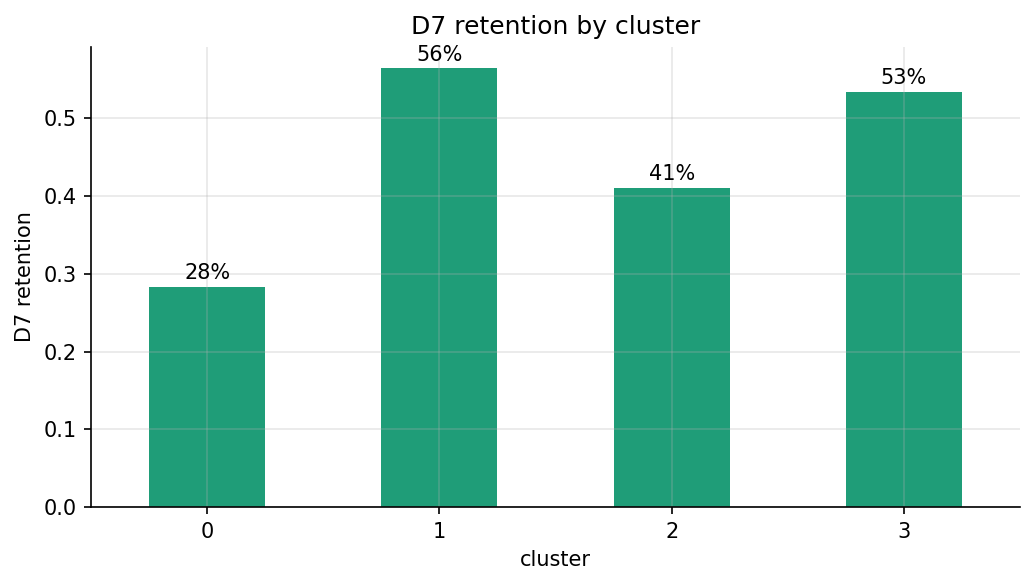

cluster
0    0.283
1    0.564
2    0.410
3    0.534
Name: retained_d7, dtype: float64

가장 잘 남는 클러스터: 1 (56%) — 이 페르소나를 시드 삼아 확장할 액션을 제안해 볼 수 있습니다.


In [12]:
# 리텐션은 클러스터링 입력이 아니라, 비지도로 나눈 군집을 '사후에' 평가하는 지표
retention = df_labeled.groupby('cluster')['retained_d7'].mean().sort_index()

fig, ax = plt.subplots(figsize=(7, 4))
retention.plot.bar(ax=ax, color='#1f9d78')
ax.set_xlabel('cluster'); ax.set_ylabel('D7 retention'); ax.set_title('D7 retention by cluster')
plt.xticks(rotation=0)
for i, v in enumerate(retention):
    ax.text(i, v + 0.01, f'{v:.0%}', ha='center')
plt.tight_layout(); plt.show()

print(retention.round(3))
print('\n가장 잘 남는 클러스터:', int(retention.idxmax()),
      f'({retention.max():.0%}) — 이 페르소나를 시드 삼아 확장할 액션을 제안해 볼 수 있습니다.')

### 8.5.5.3. 라벨 적재 & 모델 저장/로드

클러스터가 유의미하다고 판단되면, 유저별 라벨을 저장하고 모델을 파일로 남겨 둡니다.
이때 라벨 번호는 신규/기존 각각의 모델 기준이라 같은 0번이라도 두 그룹에서 다른 패턴을 뜻하므로,
`new_flag`를 라벨과 함께 저장해 어느 모델의 라벨인지 구분해 둡니다. 이렇게 해두면 시간이 지나도 같은 기준으로 유저 패턴을 지표화하며 사용 여정을 관리할 수
있습니다. (여기서는 라벨을 로컬 CSV로 저장합니다)

다만 한 가지 주의할 점이 있는데요. KMeans 모델은 표준화된 공간에서 학습됐기 때문에, 나중에 새 유저 데이터를 이 모델에 넣으려면 학습 때 사용했던 StandardScaler로 똑같이 변환해 줘야 합니다. 모델만 저장하면 이 변환 기준이 사라져 버리니, scaler 객체도 함께 pickle로 저장해 두시는 걸 추천드립니다.

In [13]:
os.makedirs('output', exist_ok=True); os.makedirs('models', exist_ok=True)

# 신규/기존 라벨을 합쳐 적재 (실서비스의 테이블 적재를 로컬 CSV로 대체)
df_all = pd.concat([df_new, df_old])[['user_id', 'new_flag', 'label']]
df_all.to_csv('output/user_labels.csv', index=False)
print(f'saved {len(df_all):,} labels -> output/user_labels.csv')

# 모델은 scaler 와 함께 pickle 로 저장 — 다음 분석에서도 같은 기준으로 라벨을 매긴다
for model, scaler, path in [(model_new, scaler_new, 'models/kmeans_new_user.pkl'),
                            (model_old, scaler_old, 'models/kmeans_old_user.pkl')]:
    pickle.dump({'scaler': scaler, 'model': model}, open(path, 'wb')); print(f'Model saved to {path}')

# 로드 일관성 확인: 저장해 둔 scaler 로 변환한 뒤 예측해야 같은 라벨이 재현된다
loaded = pickle.load(open('models/kmeans_new_user.pkl', 'rb'))
relabels = loaded['model'].predict(loaded['scaler'].transform(X_new))
print('reloaded model clusters:', loaded['model'].n_clusters,
      '| 라벨 재현 일치율:', f"{(relabels == labels_new).mean():.0%}")

saved 2,400 labels -> output/user_labels.csv


Model saved to models/kmeans_new_user.pkl
Model saved to models/kmeans_old_user.pkl


reloaded model clusters: 4 | 라벨 재현 일치율: 100%


## 마무리 — 기술만큼 중요한 해석

KMeans 결과도 결국 어떤 해석과 인사이트가 붙느냐에 따라 가치가 달라집니다. 아무리 좋은
결과라도 팀의 공감을 얻지 못하면 실제 액션으로 이어지지 않죠. 페르소나 네이밍처럼 상대가
이해하기 쉬운 형태로 결과를 포장하고, 리텐션 같은 핵심 지표와 연결해 "그래서 무엇을 할
것인가"까지 제안하는 것 — 기술만큼 중요한 데이터 분석가의 역량입니다.